# <center>House Price Prediction</center> #

#### AIM:

To predict house prices accurately using machine learning algorithms and identify the key features that affect housing prices.

#### PRE-REQUISITES:

1. Computer with Python Installed
2. Jupyter Notebook on Google Colab
3. Familiarity with NumPy, Pandas, Matplotlib, Seaborn, Scikit Learn
4. Knowledge on Machine Learning

#### Housing Dataset:

* The Housing Dataset contains information about residential properties, including features such as area,number of bedrooms,bathrooms,stories,parking spaces, and furnishing status.
* It is used to analyze the factors that influence house prices and predictive models.
* Dataset Source: 🔗 https://www.kaggle.com/datasets/yasserh/housing-prices-dataset

#### Import the Basic Libraries

In [1]:
import pandas as pd
import numpy as np

#### Task 1 -- Data Loading & Exploration

##### Load the csv file using pandas

In [2]:
df = pd.read_csv('Housing.csv')
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


##### Display the first 10 rows

In [3]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


##### Check how many rows and columns are there

In [4]:
print("Rows and Columns:",df.shape)

Rows and Columns: (545, 13)


##### Identify which column is the target (Price) and which are features

In [5]:
# Target Column
y = df['price']
print("Target Column:")
print(y.name)

# Feature columns
X = df.drop('price',axis=1)
print("\nFeature Column:")
print(X.columns.tolist())

Target Column:
price

Feature Column:
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


##### Check for missing values in each column

In [6]:
print("Missing Values:\n:")
print(df.isnull().sum())

Missing Values:
:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [7]:
# Data types
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None


#### Task 2 -- Data Cleaning

##### Handle missing values(fill or drop, whichever fits the column)

In [8]:
# Fill categorical columns
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numerical columns
numerical_cols = df.select_dtypes(exclude='object').columns
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

print("Missing values handled successfully")

Missing values handled successfully


##### Remove Duplicates

In [9]:
#Check duplicates
print("Duplicated Rows:",df.duplicated().sum())
# Remove Duplicates
df.drop_duplicates(inplace=True)

Duplicated Rows: 0


##### Convert Categorical Columns into numeric form using One-Hot Encoding

In [10]:
df = pd.get_dummies(df,columns=['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea','furnishingstatus'],drop_first=True).astype(int)
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0


##### Keep only the columns that are meaning for predicting prices

In [11]:
# Keep Meaning columns
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes',
       'airconditioning_yes', 'prefarea_yes',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')

In [12]:
X = df.drop('price',axis=1)
y = df['price']

In [13]:
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0


### Task 3 -- Model Building

##### Split the dataset into training and test sets(80/20)

In [14]:
# Split the dataset into training and test sets(80/20)
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.20,random_state=42)

##### Train a Linear Regression Model to predict house price

In [15]:
from sklearn.linear_model import LinearRegression
# create a model
lr = LinearRegression()
# Train a model
lr.fit(X_train,y_train)
# Prediction
y_pred_lr = lr.predict(X_test)

##### Evaluate it using MAE, RMSE, and R<sup>2</sup> Score

In [16]:
# Evaluate it using MAE, RMSE, and R^2 Score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
# MAE
mae = mean_absolute_error(y_test,y_pred_lr)
# RMSE
rmse = np.sqrt(mean_squared_error(y_test,y_pred_lr))
# R^2 Score
r2 = r2_score(y_test,y_pred_lr)

print("Mean Absolute Error(MAE):",mae)
print("Root Mean Squared Error(RMSE):",rmse)
print("R^2 Score:",r2)

Mean Absolute Error(MAE): 932640.4376620095
Root Mean Squared Error(RMSE): 1251802.9261171822
R^2 Score: 0.5503175979041723


The Linear Regression model achieved an R<sup>2</sup> Score of 0.55, indicating that it explains approximately 55% of the variance in house prices. The MAE and RMSE values show a moderate prediction error. Overall, the model demonstrates satisfactory performance for a baseline house price prediction system.

##### Train a second model -- Random Forest

In [17]:
# Train a second model -- Random Forest
from sklearn.ensemble import RandomForestRegressor
# create a model
rf = RandomForestRegressor()
# Train a model
rf.fit(X_train,y_train)
# Prediction
y_pred_rf = rf.predict(X_test)

##### Evaluate Random Forest

In [18]:
# Evaluate Random Forest
from sklearn.metrics import  mean_absolute_error, mean_squared_error, r2_score
import numpy as np
# MAE
mae_rf = mean_absolute_error(y_test,y_pred_rf)
# RMSE
rmse_rf = np.sqrt(mean_squared_error(y_test,y_pred_rf))
# R^2 Score
r2_rf = r2_score(y_test,y_pred_rf)

print("Random Forest Results:")
print("Mean Absolute Error(MAE):",mae_rf)
print("Root Mean Squared Error(RMSE):",rmse_rf)
print("R^2 Score:",r2_rf)

Random Forest Results:
Mean Absolute Error(MAE): 953420.7912844036
Root Mean Squared Error(RMSE): 1292181.381113746
R^2 Score: 0.5208395925841343


##### Compare Both the Models Performance

In [19]:
# Compare Both Models
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae,mae_rf],
    "RMSE": [rmse,rmse_rf],
    "R^2 Score": [r2,r2_rf]
})
print(comparison)

               Model            MAE          RMSE  R^2 Score
0  Linear Regression  932640.437662  1.251803e+06   0.550318
1      Random Forest  953420.791284  1.292181e+06   0.520840


Both Linear Regression and Random Forest Regressor were trained and evaluated using MAE,RMSE, and R<sup>2</sup> Score. The Linear Regression model performed slightly better on this dataset, achieving a lower MAE(932,640.44), lower RMSE(1,251,802.93), and a higher R<sup>2</sup> Score(0.5503) compared to the Random Forest Regressor. Therefore, Linear Regression was selected as the better-performing model for predicting house prices in this analysis.

### Task 4 -- Visualization(Minimum 3 charts)

#### Chart 1: Histogram showing the distribution of house prices

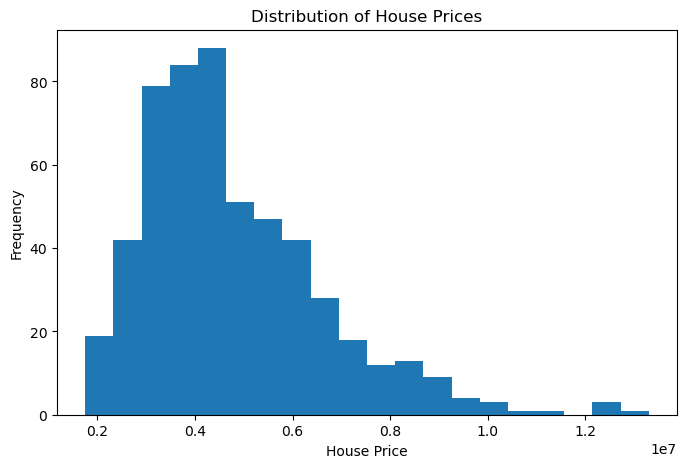

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df['price'],bins=20)
plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.savefig("Price_Distribution.png")
plt.show()

#### Chart 2: Correlation heatmap showing which features relate most strongly to price

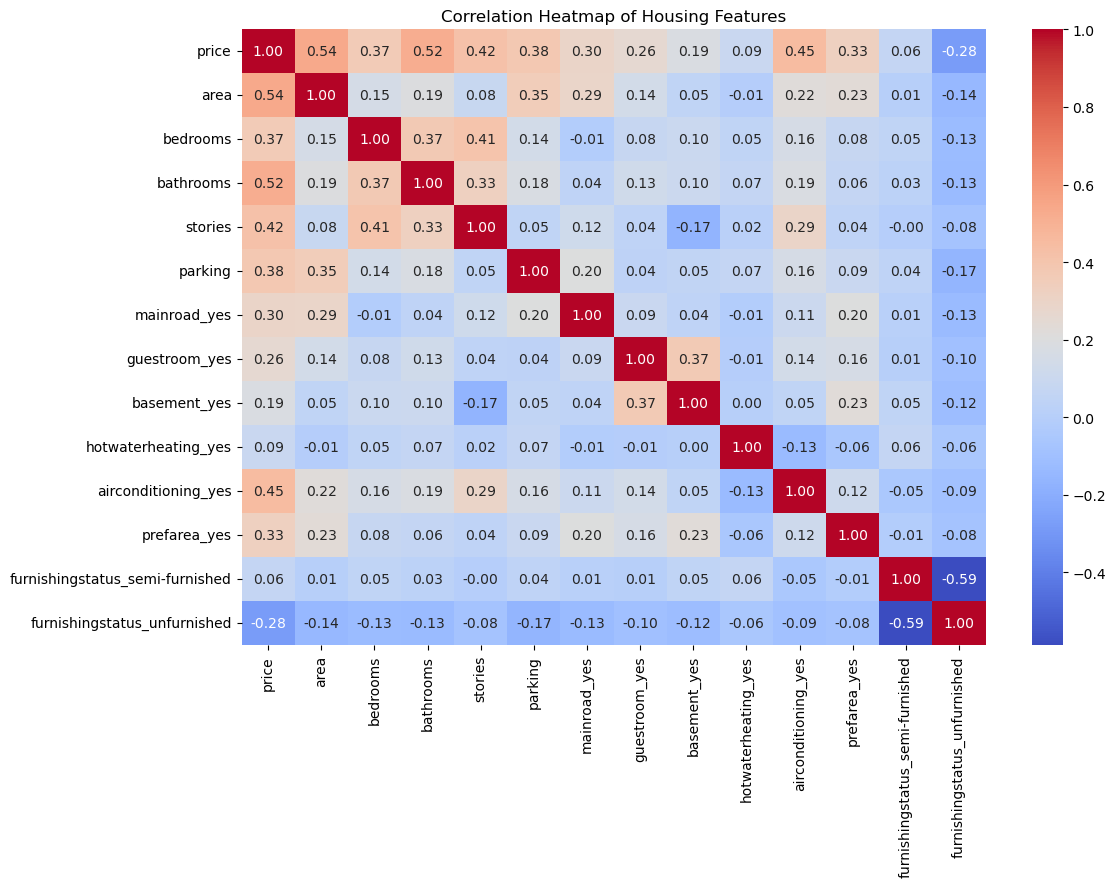

In [21]:
import seaborn as sns
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title("Correlation Heatmap of Housing Features")
plt.savefig("Correlation_Heatmap.png")
plt.show()

#### Chart 3: Actual vs Predicted Prices

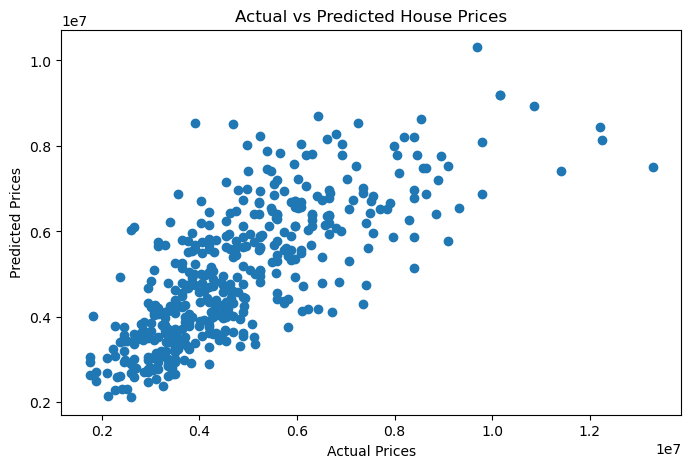

In [23]:
plt.figure(figsize=(8,5))
plt.scatter(y_test,y_pred_lr)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.savefig("Actual_vs_Predicted.png")
plt.show()

### Task 5 -- Insights & Summary

##### Which features influence house price the most?
##### How accurate was your model (in plain terms)?
##### What surprised you in the data?
##### One recommendation for a real estate business based on your findings.

The analysis showed that features such as area, number of bathrooms, stories, and air conditioning had the strongest influence on house prices. The Linear Regression model achieved an R<sup>2</sup> score of approximately 0.55, meaning it could explain about 55% of the variation in house prices, which indicates moderate predictive accuracy. One interesting observation was that some houses with similar areas had significantly different prices due to other factors such as location-related features and amenities. The data also showed that the bigger houses were more expensive. According to these results, real estate businesses should give more attention to properties with larger areas and better amenities, as these are very important factors that contribute to higher property prices and customer demand.

### Conclusion:

The project successfully developed a house price prediction model using machine learning techniques. After comparing Linear Regression and Random Forest Regressor, Linear Regression provided slightly better performance on this dataset. The analysis also showed that area, bathrooms, stories, and air conditioning are among the most influential factors affecting house prices.